<a href="https://colab.research.google.com/github/Saaj369/Computing-Moment-of-Inertia-Tensor-of-Polyhedra/blob/main/Fast_and_accurate_computation_of_polyhedral_mass_properties.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fast and accurate computation of polyhedral mass properties

In dynamic simulations of rigid bodies the mass properties of the bodies are required to perform the computations. Without the mass properties such as center of mass, moment of intertia tensor, we can not perform the accurate rigidbody simulations. At first glance it gives a sense (atleast for me) that this should not be a complex thing but it turns out it is.
In order to obtain mass properties, one encounters surface and volume integrations, and this is the core of the complexity. How to perform these integrations? We need a fast robust algorithm to perform such integrations. Now this paper titled "[Fast and Accurate Computation of Polyhedral Mass Properties](https://www.tandfonline.com/doi/epdf/10.1080/10867651.1996.10487458?needAccess=true)" describes a very elegant approach to calculate mass properties of a polyhedral properties.

The approach described in the paper is about calculating the mass properties in the body frame and then one can easily transform them to the world coordinate.
Here I will describe the approach conceptually, for much regorous mathematical description please look at the paper.

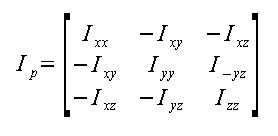
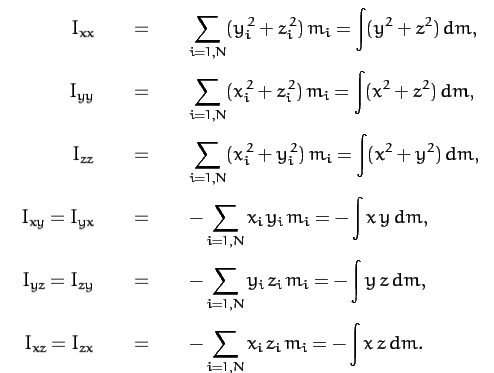

So we can see that at the end of the world we need to calculate few volume integrals (dm = pdv; p is density and dv is infinitesimal volume). Let us denote our volume integral like this-
Iv = ∫∫∫ f(x,y,z)dv

In [ ]:
# @title Imports
import numpy as np
import json, re

In [ ]:
# @title Polygon Class for calculating surface integrations
class Polygon:
  def __init__(self, verts):
    self.verts = np.array(verts)
    self.normal = None
    self.w = None
    self.ints = None
    self.pim = None
    self.abc = None
    self.evaluateNormal()

  def evaluateNormal(self):
    v1 = self.verts[1] - self.verts[0]
    v2 = self.verts[2] - self.verts[1]
    normal = np.cross(v1,v2)
    normal = normal / np.linalg.norm(normal)
    w = -1 * np.dot(normal, self.verts[0])
    self.normal, self.w = normal, w


  def calculateIntegrations(self):
    polygon = self.verts
    norm_vec = self.normal
    c = np.argmax(np.abs(norm_vec))
    a = (c + 1)%3
    b = (c + 2)%3
    self.abc = (a,b,c)
    w = self.w

    pis_matrix = np.zeros((4,4))
    p1, pa, pb, pa2, pab, pb2, pa3, pa2b, pab2, pb3 = [0]*10
    k = len(polygon)
    for e in range(k):
      ae, be = polygon[e][a], polygon[e][b]
      ae1, be1 = polygon[(e+1)%k][a], polygon[(e+1)%k][b]
      dae, dbe = ae1 - ae, be1 - be

      p1 = dbe * (ae1 + ae)
      pa = dbe * (ae1**2 + ae1*ae + ae**2)
      pb = dae * (be1**2 + be1*be + be**2)
      pa2 = dbe * (ae1**3 + ae1**2*ae + ae1*ae**2 + ae**3)
      pab = dbe * (be1*(3*ae1**2+2*ae1*ae+ae**2) + be*(ae1**2+2*ae*ae1+3*ae**2))
      pb2 = dae * (be1**3 + be1**2*be + be1*be**2 + be**3)
      pa3 = dbe * (ae1**4+ae1**3*ae+ae1**2*ae**2+ae1*ae**3+ae**4)
      pa2b = dbe * (be1*(4*ae1**3+3*ae1**2*ae+2*ae1*ae**2+ae**3) + be*(ae1**3+2*ae1**2*ae+3*ae1*ae**2+4*ae**3))
      pab2 = dae * (ae1*(4*be1**3+3*be1**2*be+2*be1*be**2+be**3) + ae*(be1**3+2*be1**2*be+3*be1*be**2+4*be**3))
      pb3 = dae * (be1**4+be1**3*be+be1**2*be**2+be1*be**3+be**4)

      temp = np.array([
        [ p1,   pa,  pa2, pa3],
        [ pb,  pab, pa2b,   0],
        [pb2, pab2,    0,   0],
        [pb3,    0,    0,   0]
      ])
      pis_matrix += temp

    sign_nc = norm_vec[c] / abs(norm_vec[c])
    coefficient_matrix = np.array([
        [  1/2,   1/6, 1/12, 1/20],
        [ -1/6,  1/24, 1/60,    0],
        [-1/12, -1/60,    0,    0],
        [-1/20,     0,    0,    0]
    ])
    coefficient_matrix *= sign_nc
    pim = pis_matrix * coefficient_matrix
    self.pim = pim
    na, nb, nc = norm_vec[a], norm_vec[b], norm_vec[c]
    anc = np.abs(nc)

    Ia = pim[0,1] / anc
    Ib = pim[1,0] / anc
    Ic = -(na*pim[0,1] + nb*pim[1,0] + w*pim[0,0]) / (anc*nc)
    Ia2 = pim[0,2] / anc
    Ib2 = pim[2,0] / anc
    Ic2 = (na**2*pim[0,2] + 2*na*nb*pim[1,1] + nb**2*pim[2,0] + 2*na*w*pim[0,1] + 2*nb*w*pim[1,0] + w**2*pim[0,0]) / (anc*nc**2)
    Ia3 = pim[0,3] / anc
    Ib3 = pim[3,0] / anc
    Ic3 = -(na**3*pim[0,3] + 3*na**2*nb*pim[1,2] + 3*na*nb**2*pim[2,1] + nb**3*pim[3,0] + 3*na**2*w*pim[0,2] + 6*na*nb*w*pim[1,1] + 3*nb**2*w*pim[2,0] + 3*na*w**2*pim[0,1] + 3*nb*w**2*pim[1,0] + w**3*pim[0,0]) / (anc*nc**3)
    Ia2b = pim[1,2] / anc
    Ib2c = -(na*pim[2,1] + nb*pim[3,0] + w*pim[2,0]) / (anc*nc)
    Ic2a = (na**2*pim[0,3] + 2*na*nb*pim[1,2] + nb**2*pim[2,1] + 2*na*w*pim[0,2] + 2*nb*w*pim[1,1] + w**2*pim[0,1]) / (anc*nc**2)

    if a == 0:
      poly_int = np.array([
          [  Ia,   Ib,   Ic],
          [ Ia2,  Ib2,  Ic2],
          [ Ia3,  Ib3,  Ic3],
          [Ia2b, Ib2c, Ic2a]
      ])
    elif b == 0:
      poly_int = np.array([
        [  Ib,   Ic,   Ia],
        [ Ib2,  Ic2,  Ia2],
        [ Ib3,  Ic3,  Ia3],
        [Ib2c, Ic2a, Ia2b]
      ])
    else:
      poly_int = np.array([
          [  Ic,   Ia,   Ib],
          [ Ic2,  Ia2,  Ib2],
          [ Ic3,  Ia3,  Ib3],
          [Ic2a, Ia2b, Ib2c]
      ])


    self.ints = poly_int


In [ ]:
# @title Polyhedral class for Volume integrations
class Polyhedral:
  def __init__(self, polygons:tuple, **kwargs):
    self.polygons = polygons
    self.shift_com_origin = kwargs.get('shift_com_origin', False)
    self.calculated = {
        'mass' : kwargs.get('mass', None),
        'density' : kwargs.get('density', 1),
        'volume' : None,
        'T' : None,
        'com' : None,
        'inertia' : None,
        'com_inertia' : None
    }

  @classmethod
  def fromObjfile(cls, filepath:str, **kwargs):
    obj_dict = {'o':'', 'v':[], 'f':[]}
    with open(filepath, 'r') as obj:
      lines = obj.readlines()
      for line in lines:
        line_list = line.split()
        match line_list[0]:
          case 'o':
            obj_dict['o'] = line_list[1]
          case 'v':
            obj_dict['v'].append([float(coord) for coord in line_list[1:]])
          case 'f':
            obj_dict['f'].append([int(coord.split('//')[0]) for coord in line_list[1:]])

    polys = [Polygon(verts=[obj_dict['v'][iv-1] for iv in face]) for face in obj_dict['f']]
    return cls(polygons=tuple(polys), **kwargs)

  def generateObjectJSON(self, filename:str, obj:str):
    deci = 5
    if any(value is None for value in self.calculated.values()):
      self.calculatePhysicalQuantities()
    verts, iv = [], 0
    faces, normals = [], []
    for polygon in self.polygons:
      polyverts = polygon.verts.tolist()
      normals.append(polygon.normal.round(decimals=deci).tolist())
      face = []
      for polyvert in polyverts:
        if polyvert not in verts:
          verts.append(polyvert)
          face.append(iv)
          iv += 1
        else:
          face.append(verts.index(polyvert))
      faces.append(face)


    objJson = {
        'object':obj,
        'density' : self.calculated['density'],
        'mass' : self.calculated['mass'],
        'volume' : self.calculated['volume'],
        'verts' : verts,
        'faces' : faces,
        'normals' : normals,
        'com' : self.calculated['com'].round(decimals = deci).tolist(),
        'inertia' : self.calculated['inertia'].round(decimals = deci).tolist(),
        'com_inertia' : self.calculated['com_inertia'].round(decimals = deci).tolist()
        }

    pretty_data = json.dumps(objJson, indent = 4)
    pretty_data = re.sub(r'\[\s+([\d\.\-,\s]+)\s+\]',
               lambda m: "[" + " ".join(m.group(1).split()) + "]", pretty_data)
    with open(filename, 'w') as outfile:
      outfile.write(pretty_data)
      # json.dump(objJson, outfile, indent = 2)

  def calculateVolumeIntegrals(self):
    T = np.zeros((4,3))
    for polygon in self.polygons:
      polygon.calculateIntegrations()

      normal_mat = np.array([polygon.normal]*4)
      T += normal_mat * polygon.ints

    T[1] *= 1/2
    T[2] *= 1/3
    T[3] *= 1/2
    self.calculated['T'] = T

  def calculatePhysicalQuantities(self):
    if self.calculated['T'] is None:
      self.calculateVolumeIntegrals()

    volume = self.calculated['T'][0,0]
    if self.calculated['mass'] is None:
      mass = self.calculated['density'] * volume
      density = self.calculated['density']
    else:
      density = self.calculated['mass'] / volume
      mass = self.calculated['mass']

    rcom = self.calculated['T'][1] * (density / mass)

    x2, y2, z2 = self.calculated['T'][2]
    xy, yz, zx = self.calculated['T'][3]
    Ixx = y2 + z2
    Iyy = z2 + x2
    Izz = x2 + y2
    Ixy, Iyz, Izx = xy, yz, zx
    I = density * np.array([
        [Ixx, -Ixy, -Izx],
        [-Ixy, Iyy, -Iyz],
        [-Izx, -Iyz, Izz]
    ])
    rx,ry,rz = rcom
    Icxx = density*Ixx - mass * (ry**2+rz**2)
    Icyy = density*Iyy - mass * (rz**2+rx**2)
    Iczz = density*Izz - mass * (rx**2+ry**2)
    Icxy = density*Ixy - mass * (rx*ry)
    Icyz = density*Iyz - mass * (ry*rz)
    Iczx = density*Izx - mass * (rz*rx)
    Icom = np.array([
        [Icxx, -Icxy, -Iczx],
        [-Icxy, Icyy, -Icyz],
        [-Iczx, -Icyz, Iczz]
    ])

    self.calculated['volume'] = volume
    self.calculated['mass'] = mass
    self.calculated['density'] = density
    self.calculated['com'] = rcom
    self.calculated['inertia'] = I
    self.calculated['com_inertia'] = Icom



In [ ]:
# @title Testing on tetrahedron
f1 = Polygon(verts = [(0,0,0), (0,4,0), (5,0,0)])
f2 = Polygon(verts = [(0,0,0), (5,0,0), (0,0,3)])
f3 = Polygon(verts = [(0,0,0), (0,0,3), (0,4,0)])
f4 = Polygon(verts = [(5,0,0), (0,4,0), (0,0,3)])

tetrahedron = Polyhedral(polygons = (f1,f2,f3,f4))
tetrahedron.calculateVolumeIntegrals()
tetrahedron.calculatePhysicalQuantities()
tetrahedron.generateObjectJSON('tetrahedron.json','tetrahedron')
tetrahedron.calculated['T']

array([[10. , 10. , 10. ],
       [12.5, 10. ,  7.5],
       [25. , 16. ,  9. ],
       [10. ,  6. ,  7.5]])

In [ ]:
# @title Testing on cube
f1 = Polygon(verts = [(-10, -10, -10), (-10, 10, -10), (10, 10, -10), (10, -10, -10)])
f2 = Polygon(verts = [(-10, -10, 10), (10, -10, 10), (10, 10, 10), (-10, 10, 10)])
f3 = Polygon(verts = [(-10, -10, -10), (10, -10, -10), (10, -10, 10), (-10, -10, 10)])
f4 = Polygon(verts = [(10, 10, 10), (10, 10, -10), (-10, 10, -10), (-10, 10, 10)])
f5 = Polygon(verts = [(10, -10, -10), (10, 10, -10), (10, 10, 10), (10, -10, 10)])
f6 = Polygon(verts = [(-10, -10, -10), (-10, -10, 10), (-10, 10, 10), (-10, 10, -10)])

cube = Polyhedral(polygons = (f1, f2, f3, f4, f5, f6))
cube.calculateVolumeIntegrals()
cube.calculatePhysicalQuantities()
cube.generateObjectJSON('cube20.json','cube')
cube.calculated['T']

array([[  8000.        ,   8000.        ,   8000.        ],
       [     0.        ,      0.        ,      0.        ],
       [266666.66666667, 266666.66666667, 266666.66666667],
       [     0.        ,      0.        ,      0.        ]])

In [ ]:
# @title Testing on cube.obj(blender)
cube_fromfile = Polyhedral.fromObjfile('cube_10cm.obj', density = 2000)
cube_fromfile.calculateVolumeIntegrals()
cube_fromfile.generateObjectJSON('cube.json','cube')
cube_fromfile.calculated['T']

array([[1.00000000e-03, 1.00000000e-03, 1.00000000e-03],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [8.33333333e-07, 8.33333333e-07, 8.33333333e-07],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [ ]:
cube_fromfile.calculated

{'mass': np.float64(2.0000000000000004),
 'density': 2000,
 'volume': np.float64(0.0010000000000000002),
 'T': array([[1.00000000e-03, 1.00000000e-03, 1.00000000e-03],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [8.33333333e-07, 8.33333333e-07, 8.33333333e-07],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]),
 'com': array([0., 0., 0.]),
 'inertia': array([[ 0.00333333, -0.        , -0.        ],
        [-0.        ,  0.00333333, -0.        ],
        [-0.        , -0.        ,  0.00333333]]),
 'com_inertia': array([[ 0.00333333, -0.        , -0.        ],
        [-0.        ,  0.00333333, -0.        ],
        [-0.        , -0.        ,  0.00333333]])}

In [ ]:
# @title Testing on cuboid.obj(blender)
cuboid_fromfile = Polyhedral.fromObjfile('cuboid_15cm.obj', density = 2500) # density of granite
cuboid_fromfile.calculateVolumeIntegrals()
cuboid_fromfile.generateObjectJSON('cuboid_granite.json','cuboid')
cuboid_fromfile.calculated['T']

array([[5.66054602e-04, 5.66054602e-04, 5.66054602e-04],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.32667419e-07, 1.06183358e-06, 7.32044093e-08],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [ ]:
cuboid_fromfile.calculated

{'mass': np.float64(1.4151365045842799),
 'density': 2500,
 'volume': np.float64(0.000566054601833712),
 'T': array([[5.66054602e-04, 5.66054602e-04, 5.66054602e-04],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [4.32667419e-07, 1.06183358e-06, 7.32044093e-08],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]),
 'com': array([0., 0., 0.]),
 'inertia': array([[ 0.00283759, -0.        , -0.        ],
        [-0.        ,  0.00126468, -0.        ],
        [-0.        , -0.        ,  0.00373625]]),
 'com_inertia': array([[ 0.00283759, -0.        , -0.        ],
        [-0.        ,  0.00126468, -0.        ],
        [-0.        , -0.        ,  0.00373625]])}

In [ ]:
# @title Testing on slope.obj(blender)
slope_fromfile = Polyhedral.fromObjfile('slope_100cm.obj', density = 6000) # density of iron
slope_fromfile.calculateVolumeIntegrals()
slope_fromfile.generateObjectJSON('slop_iron.json','slope')
slope_fromfile.calculated['T']

array([[ 1.02917210e-01,  1.02917210e-01,  1.02917210e-01],
       [ 0.00000000e+00, -1.41182127e-08, -1.41182127e-08],
       [ 2.70318849e-03,  1.77917091e-03,  2.23690996e-03],
       [ 0.00000000e+00,  9.35895419e-04,  0.00000000e+00]])

In [ ]:
slope_fromfile.calculated

{'mass': np.float64(617.5032600647879),
 'density': 6000,
 'volume': np.float64(0.102917210010798),
 'T': array([[ 1.02917210e-01,  1.02917210e-01,  1.02917210e-01],
        [ 0.00000000e+00, -1.41182127e-08, -1.41182127e-08],
        [ 2.70318849e-03,  1.77917091e-03,  2.23690996e-03],
        [ 0.00000000e+00,  9.35895419e-04,  0.00000000e+00]]),
 'com': array([ 0.0000000e+00, -1.3718029e-07, -1.3718029e-07]),
 'inertia': array([[24.09648525, -0.        , -0.        ],
        [-0.        , 29.64059072, -5.61537252],
        [-0.        , -5.61537252, 26.8941564 ]]),
 'com_inertia': array([[24.09648525, -0.        , -0.        ],
        [-0.        , 29.64059072, -5.61537252],
        [-0.        , -5.61537252, 26.8941564 ]])}

In [ ]:
# @title Testing on icosphere.obj(blender)
icosphere_fromfile = Polyhedral.fromObjfile('icos_5cm.obj', density = 7000)
icosphere_fromfile.calculateVolumeIntegrals()
icosphere_fromfile.generateObjectJSON('icos_iron.json','icosphere')
icosphere_fromfile.calculated['T']

array([[ 6.95998407e-05,  6.95998407e-05,  6.95998407e-05],
       [-1.98523347e-23,  6.61744490e-23,  1.98523347e-23],
       [ 9.16426404e-09,  9.16440461e-09,  9.16404399e-09],
       [ 1.05858813e-13, -7.73257743e-14,  1.25114620e-13]])

In [ ]:
icosphere_fromfile.calculated

{'mass': np.float64(0.4871988848586184),
 'density': 7000,
 'volume': np.float64(6.959984069408834e-05),
 'T': array([[ 6.95998407e-05,  6.95998407e-05,  6.95998407e-05],
        [-1.98523347e-23,  6.61744490e-23,  1.98523347e-23],
        [ 9.16426404e-09,  9.16440461e-09,  9.16404399e-09],
        [ 1.05858813e-13, -7.73257743e-14,  1.25114620e-13]]),
 'com': array([-2.85235347e-19,  9.50784490e-19,  2.85235347e-19]),
 'inertia': array([[ 1.28299140e-04, -7.41011690e-10, -8.75802337e-10],
        [-7.41011690e-10,  1.28298156e-04,  5.41280420e-10],
        [-8.75802337e-10,  5.41280420e-10,  1.28300681e-04]]),
 'com_inertia': array([[ 1.28299140e-04, -7.41011690e-10, -8.75802337e-10],
        [-7.41011690e-10,  1.28298156e-04,  5.41280420e-10],
        [-8.75802337e-10,  5.41280420e-10,  1.28300681e-04]])}